### meteo.data.gouv.fr Historique MENSUEL SIM2 (SAFRAN-ISBA) - Cartographie par MAILLE + fichier Excel agrégé par POLYGONE
Version pour environnement 3.11.8 (numpy V1.26.4 pas encore en V2).<br>
Ajout des indices SSWI dans le fichier excel de la moyenne par polygone (mais indices SSWI non cartographiés à ce jour)

A RESOUDRE l'affichage de l'animation dans le notebook affiche par défaut un pas de temps qui n'est pas le premier (mais l'animation est correcte).
- data : [meteo.data.gouv.fr](https://meteo.data.gouv.fr/)
- Auteur: L. Duffar, P. Freydier
--------------------------------------------------------------
C'est le 2ème script de la chaine de traitement des données SIM2 MENSUELLES
- Un 1er script permet de générer le fichier PARQUET de tous les paramètres pour la France entière, à partir des fichiers CSV originaux téléchargés automatiquement)
- Ce 2ème script de traitement PAR MAILLE est indispensable pour générer un fichier EXCEL indispensable au 3ème script
- Le 3ème script de traitement PAR POLYGONE utilise le fichier EXCEL créé précédemment pour générer des cartes agrégées par département, bassin-versant ou polygones quelconques
--------------------------------------------------------------
Ce 2EME SCRIPT produit les traitements suivants PAR MAILLE à partir d'un fichier PARQUET issu des CSV Météo-France :
- cartographie mois par mois de 6 paramètres bruts prédéterminés

- NB: les paramètre SSWI1 est lu et enregistré dans le fichier par polygone, mais ne fait pas l'objet de carte dans ce scrit
- calcul et cartographie de la moyenne interannuelle sur une période d'années choisie (un fichier geotif est produit pour la carte annuelle),
- cartographie de l'écart à cette moyenne pour chaque mois de la période d'années choisie,
- A partir des polygones fournis, le script calcule la moyenne agrégée par polygone et génère un fichier EXCEL des séries chronologiques correspondantes. Ce fichier EXCEL alimente notamment un 3EME SCRIPT de traitement par POLYGONE).

NB: Tout est personalisable en terme de secteur géographique (les paramètres ne le sont pas, à moins de faire évoluer le script)
- Zone d'intérêt (1 polygone) pour laquelle les mailles seront traitées et cartographiées (ce qui permet de travailler sur toute la France, ici la région PACA)
- Polygones multiples (fichier unique, à l'intérieur de la zone d'intérêt), sur lesquels les paramètres seront agrégeés par la moyenne (ici départements de PACA ou bassins versants de la Concession)

#### 1- Personalisation + Lecture du fichier PARQUET de tous les paramètres pour la France entière --> dataset ds
La restitution cartographique et statistique est codée pour certains paramètres prédéterminés (notamment précipitions et autres paramètres fixés dans la cellule d'initialisation)

NB: 
- Ce fichier PARQUET est une image fidèle des données originales (sous forme de dataframe pandas, en coordonnées Lambert2 étendues sans numéro de maille, avec les paramètres en colonnes)
- Un dataset xarray est produit immédiatement dans le but d'un traitement à la fois géogbraphique et temporel (Traitement multi dimentionnel)


02/08/2025 20:43
Patientez .... attendez l'affichage final de la structure du datatset xarray


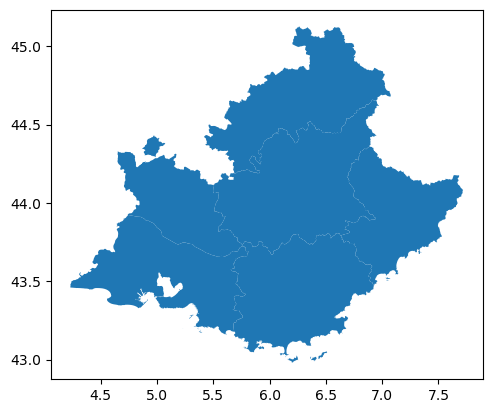

,fid,id,code,NOM,coderegion,region,geometry
0,1.0,05,05,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur,"POLYGON ((5.95112 44.75962, 5.95166 44.76019, ..."
1,2.0,04,04,Alpes-de-Haute-Provence,93,Provence-Alpes-Côte d'Azur,"POLYGON ((5.63131 44.15042, 5.63345 44.15060, ..."
2,3.0,83,83,Var,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9..."
3,4.0,13,13,Bouches-du-Rhône,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1..."
4,5.0,84,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3..."
5,6.0,06,06,Alpes-Maritimes,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5..."


Liste complète des paramètres : Index(['PRENEI_MENS', 'PRELIQ_MENS', 'PRETOTM_MENS', 'T_MENS', 'EVAP_MENS',
       'ETP_MENS', 'PE_MENS', 'SWI_MENS', 'DRAINC_MENS', 'RUNC_MENS',
       'SPI1_MENS', 'SPI3_MENS', 'SPI6_MENS', 'SPI12_MENS', 'SSWI1_MENS',
       'SSWI3_MENS', 'SSWI6_MENS', 'SSWI12_MENS', 'ECOULEMENT_MENS'],
      dtype='object')
Paramètres conservés : Index(['PRENEI_MENS', 'PRETOTM_MENS', 'PE_MENS', 'T_MENS', 'EVAP_MENS',
       'ETP_MENS', 'SWI_MENS', 'SSWI1_MENS', 'SSWI3_MENS', 'SSWI6_MENS',
       'SSWI12_MENS'],
      dtype='object')
Lecture du fichier PARQUET terminée. Le Dataset xarray est le suivant sous sa forme initiale, avant sa transformation géographique:


PRENEI_MENS  PRETOTM_MENS  PE_MENS  T_MENS  EVAP_MENS  \
LAMBX LAMBY DATE                                                                
600   24010 1958-08-01          0.0         101.1     42.2    16.2       58.9   
            1958-09-01          0.0          87.4     27.7    16.5       59.7   
            1958-10-01          0.0          90.4     49.6    12.4       40.8   
            1958-11-01          0.0          63.8     38.9     9.5       24.9   
            1958-12-01          0.0         114.1     75.4     8.0       38.7   
...                             ...           ...      ...     ...        ...   
11960 17450 2025-03-01          0.0          76.5     10.2    11.6       66.3   
            2025-04-01          0.0          96.9     17.7    14.8       79.2   
            2025-05-01          0.0          27.9    -67.7    17.6       95.6   
            2025-06-01          0.0           1.2    -47.3    24.6       48.5   
            2025-07-01          0.0          16.7    -19.1    25.5       35.8   

                        ETP_MENS  SWI_MENS  SSWI1_MENS  SSWI3_MENS  \
LAMBX LAMBY DATE                                                     
600   24010 1958-08-01      74.1     0.407       -0.77         NaN   
            1958-09-01      59.5     0.460       -0.05         NaN   
            1958-10-01      35.3     0.649        0.69       -0.01   
            1958-11-01      22.5     0.751        0.36        0.35   
            1958-12-01      17.1     0.810       -0.25        0.35   
...                          ...       ...         ...         ...   
11960 17450 2025-03-01      68.1     0.877        0.49        0.49   
            2025-04-01      90.2     0.818        0.89        0.76   
            2025-05-01     137.9     0.578        0.27        0.55   
            2025-06-01     200.0     0.273       -0.85        0.27   
            2025-07-01     175.2     0.106       -1.39       -0.41   

                        SSWI6_MENS  SSWI12_MENS  
LAMBX LAMBY DATE                                 
600   24010 1958-08-01         NaN          NaN  
            1958-09-01         NaN          NaN  
            1958-10-01         NaN          NaN  
            1958-11-01         NaN          NaN  
            1958-12-01         NaN          NaN  
...                            ...          ...  
11960 17450 2025-03-01        0.15        -1.03  
            2025-04-01        0.51        -0.51  
            2025-05-01        0.63        -0.14  
            2025-06-01        0.48         0.01  
            2025-07-01        0.34         0.06  

[7953168 rows x 11 columns]

<xarray.Dataset> Size: 1GB
Dimensions:       (LAMBX: 142, LAMBY: 134, DATE: 804)
Coordinates:
  * LAMBX         (LAMBX) int32 568B 60000 76000 84000 ... 1188000 1196000
  * LAMBY         (LAMBY) int32 536B 1617000 1625000 1633000 ... 2673000 2681000
  * DATE          (DATE) datetime64[ns] 6kB 1958-08-01 1958-09-01 ... 2025-07-01
Data variables:
    PRENEI_MENS   (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    PRETOTM_MENS  (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    PE_MENS       (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    T_MENS        (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    EVAP_MENS     (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    ETP_MENS      (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    SWI_MENS      (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    SSWI1_MENS    (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    SSWI3_MENS    (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    SSWI6_MENS    (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan
    SSWI12_MENS   (LAMBX, LAMBY, DATE) float64 122MB nan nan nan ... nan nan nan

In [ ]:
#================================
# Auteur: L. Duffar
# Mars 2024, Rév. juillet 2025
#================================
import pandas as pd
import geopandas as gpd
import xarray as xr
import os
from datetime import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors

#========= Personalisation
folder_in= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\France"
file_parquet= "SIM2 MENS FRANCE 1958_2025-07 Lamb2.parquet"
folder_out= r"X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025"

# Polygone de la région d'intérêt (WGS84)
file_polygone_interet= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Région PACA_WGS84.gpkg"

# fichier SHP des polygones d'agrégation spatiale (multi-polygones WGS84 inclus dans la zone d'intéret, dans une couche unique)
file_polygones= r"X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out\shp\BV_Verdon+Durance+Siagne+Biançon.gpkg"
file_polygones= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Départements PACA.shp"
# nom de la colonne du fichier SHP qui contient l'IDENTIFIANT de polygone voulu pour les cartes
nom_champ_polygone = 'code'
nom_champ_polygone = 'nom'
# Nouveau nom de COLONE IDENTIFIANT de polygone dans le geodataframe tiré du fichier SHP
# nom_colonne_polygone = 'DEPARTEMENT'
nom_colonne_polygone = 'NOM'

#========= initialisation
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
print("Patientez .... attendez l'affichage final de la structure du datatset xarray")
# crée le dossier de sortie s'il n'existe pas
if not os.path.exists(folder_out):
    os.makedirs(folder_out)

# Pamètres gérés par le script
list_param= ['PRENEI_MENS', 'PRETOTM_MENS' ,'PE_MENS' ,'T_MENS', 'EVAP_MENS', 'ETP_MENS', 'SWI_MENS'] # paramètre faisant l'objet des cartes systématiques
list_param_comp= ['SSWI1_MENS', 'SSWI3_MENS', 'SSWI6_MENS', 'SSWI12_MENS'] # Paramètres complémentaires à inclure dans le Dataset xarray, pour des traitements complémentaires

# Equivalence entre les valeurs SSWI (variable normale centrée réduite) et les périodes de retour"
dict_sswi= {'Médiane': '0', '5 ans': '+/-0.842', '10 ans': '+/-1.282', '20 ans': '+/-1.645', '50 ans': '+/-2.054', '100 ans': '+/-3.090'}

# crée un dataframe Pandas pour afficher les périodes de retour des indices SSWI avec les colonnes Période de retour et SSWI
# utilise dict_sswi pour créer le dataframe
df_sswi = pd.DataFrame({
    "Période de retour": list(dict_sswi.keys()),
    "SSWI": [value for value in dict_sswi.values()]
})

#========= Lecture du fichier shapefile de polygones
gdf = gpd.read_file(file_polygones)
# renomme la colonne des identifiants de polygones
gdf.rename(columns={ nom_champ_polygone: nom_colonne_polygone}, inplace=True)
# attributive_table = gdf.drop(columns= gdf.geometry.name)
# attributive_table
gdf.plot()
plt.show()
display(gdf)

#========= Lecture du fichier PARQUET et conversion en Dataset xarray
df= pd.read_parquet(os.path.join(folder_in, file_parquet))
# Créer un MultiIndex avec les coordonnées et la date
df.set_index(['LAMBX', 'LAMBY', 'DATE'], inplace=True)
print("Liste complète des paramètres :", df.columns)
# ne garde que les colonnes utilisées
df= df[list_param + list_param_comp]
print("Paramètres conservés :", df.columns)

# Convertir le DataFrame Pandas en Dataset xarray
ds = xr.Dataset.from_dataframe(df)
ds["LAMBX"] = ds["LAMBX"]*100 # conversion en m des coordonnées lambert2 étendues en hm 
ds["LAMBY"] = ds["LAMBY"]*100
print('Lecture du fichier PARQUET terminée. Le Dataset xarray est le suivant sous sa forme initiale, avant sa transformation géographique:')
display(df)
display(ds)

#### 2- Transformation du dataset en données géographiques --> dataset ds_spatial
Tableau tri-dimentionnel = rasters géographiques chronologiques de la France et période entières, pour tous les paramètres 

In [28]:
# Auteurs: P. Freydier, L. Duffar
# Mars 2024

import rioxarray

print(datetime.now().strftime('%d/%m/%Y %H:%M'))
ds_spatial = ds.copy()
# inscrit le CRS dans les attributs du dataset
ds_spatial = ds_spatial.rio.write_crs("IGNF:LAMBE", inplace=True)
# Définir explicitement les dimensions spatiales qui sont nommées impérativement 'x' et 'y' comme exigé par la méthode rioxarray.rio.set_spatial_dims()
ds_spatial = ds_spatial.rename({"LAMBX": "x", "LAMBY": "y"})
ds_spatial = ds_spatial.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace= True)

ds_spatial

02/08/2025 20:44


<xarray.Dataset> Size: 1GB
Dimensions:       (x: 142, y: 134, DATE: 804)
Coordinates:
  * x             (x) int32 568B 60000 76000 84000 ... 1180000 1188000 1196000
  * y             (y) int32 536B 1617000 1625000 1633000 ... 2673000 2681000
  * DATE          (DATE) datetime64[ns] 6kB 1958-08-01 1958-09-01 ... 2025-07-01
    spatial_ref   int32 4B 0
Data variables:
    PRENEI_MENS   (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    PRETOTM_MENS  (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    PE_MENS       (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    T_MENS        (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    EVAP_MENS     (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    ETP_MENS      (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    SWI_MENS      (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI1_MENS    (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI3_MENS    (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI6_MENS    (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI12_MENS   (x, y, DATE) float64 122MB nan nan nan nan ... nan nan nan nan

#### 3- Reprojection des coordonnées Lambert2 étendues en WGS84 --> dataset latlon

WGS84 est le CRS pas défaut des librairies, ce qui facilite le codage

In [29]:
# Auteurs: P. Freydier, L. Duffar
# Mars 2024

# ds_lonlat= ds_spatial.rio.write_nodata(-9999, inplace=True)# Définir explicitement la valeur nodata avant la reprojection qui ne sais pas gérer les NaN
# ds_latlon= ds_spatial.fillna(-9999) # Définir explicitement la valeur nodata avant la reprojection qui ne sais pas gérer les NaN
#======== Initialisation
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
# seuil de filtrage des valeurs élevées générées par la reprojection à la place de NaN
seuil_filtre= 1e+10

#======== Traitement
# déplacement de la latitude en première dimension spatiale, comme exigé par la fonction rioxarray.rio.reproject()
ds_latlon = ds_spatial.transpose('DATE', 'y', 'x')
display(ds_latlon)
# reprojection en latlon
ds_latlon = ds_latlon.rio.reproject("EPSG:4326")
# remplace par NaN les valeurs supérieures trés élevées générées par la méthode rioxarray.rio.reproject qui ne gère pas correctement les NaN
ds_latlon = ds_latlon.where(ds_latlon < seuil_filtre, other= float('nan'))

print ("AVERTISSEMENT: la reprojection produit inévitablement une interpolation entre les valeurs intiales SAFRAN. IL FAUDRA ETRE ATTENTIF A D'EVENTUELLES VALEURS ABERRANTES OU FAUSSEES")
print("Par exemple on constate déjà que les valeurs maximales de précipitations et de chute de neige sont plus faibles de 4% (maximum qui concernent probablement un nombre réduit de mailles).")

ds_latlon

02/08/2025 20:44


<xarray.Dataset> Size: 1GB
Dimensions:       (x: 142, y: 134, DATE: 804)
Coordinates:
  * x             (x) int32 568B 60000 76000 84000 ... 1180000 1188000 1196000
  * y             (y) int32 536B 1617000 1625000 1633000 ... 2673000 2681000
  * DATE          (DATE) datetime64[ns] 6kB 1958-08-01 1958-09-01 ... 2025-07-01
    spatial_ref   int32 4B 0
Data variables:
    PRENEI_MENS   (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    PRETOTM_MENS  (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    PE_MENS       (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    T_MENS        (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    EVAP_MENS     (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    ETP_MENS      (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    SWI_MENS      (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI1_MENS    (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI3_MENS    (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI6_MENS    (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan
    SSWI12_MENS   (DATE, y, x) float64 122MB nan nan nan nan ... nan nan nan nan

AVERTISSEMENT: la reprojection produit inévitablement une interpolation entre les valeurs intiales SAFRAN. IL FAUDRA ETRE ATTENTIF A D'EVENTUELLES VALEURS ABERRANTES OU FAUSSEES
Par exemple on constate déjà que les valeurs maximales de précipitations et de chute de neige sont plus faibles de 4% (maximum qui concernent probablement un nombre réduit de mailles).


<xarray.Dataset> Size: 1GB
Dimensions:       (DATE: 804, y: 109, x: 179)
Coordinates:
  * x             (x) float64 1kB -5.347 -5.256 -5.166 ... 10.63 10.72 10.81
  * y             (y) float64 872B 51.11 51.02 50.93 50.84 ... 41.49 41.4 41.31
  * DATE          (DATE) datetime64[ns] 6kB 1958-08-01 1958-09-01 ... 2025-07-01
    spatial_ref   int32 4B 0
Data variables:
    PRENEI_MENS   (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    PRETOTM_MENS  (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    PE_MENS       (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    T_MENS        (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    EVAP_MENS     (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    ETP_MENS      (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    SWI_MENS      (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    SSWI1_MENS    (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    SSWI3_MENS    (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    SSWI6_MENS    (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan
    SSWI12_MENS   (DATE, y, x) float64 125MB nan nan nan nan ... nan nan nan nan

#### 4- Personalisation + Clip sur la région d'intérêt -->  dataset ds_latlon clippé

La région d'intérêt est définie par un polygone quelconque en coordonnées WGS84 dans la France métropolitaire, ici la région PACA

In [30]:
#================================
# Auteurs: L. Duffar
# Mars 2025
#================================
from shapely.geometry import mapping
import rioxarray

#======== Personalisation
# racine du nom du fichier de sortie
file_out_name_root= 'SIM2 MENS Verdon+Durance+Siagne+Biançon_'
file_out_name_root= 'SIM2_MENS_PACA_'

#======== Initialisation
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
# seuil de filtrage des valeurs élevées générées par la reprojection à la place de NaN
seuil_filtre= 1e+10

# Polygone de la région d'intérêt
file_polygone= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Départements PACA.shp"
file_polygone_interet= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Région PACA_WGS84.gpkg"

#======== Traitement

# nom de la colonne du fichier SHP qui contient l'IDENTIFIANT de polygone voulu pour les cartes (utile pour nommer les polygones dans le datframe en sortie)
# nom_champ_polygone = 'code'
nom_champ_polygone = 'nom'
# Nouveau nom de COLONE IDENTIFIANT de polygone dans le geodataframe tiré du fichier SHP
# nom_colonne_polygone = 'DEPARTEMENT'
nom_colonne_polygone = 'NOM'

gdf = gpd.read_file(file_polygone_interet)
# renomme la colonne des identifiants de polygones # utile pour nommer les polygones dans le datframe en sortie
gdf.rename(columns={ nom_champ_polygone: nom_colonne_polygone}, inplace=True)
# gdf.plot()
# plt.show()
# display(gdf)

#   Clipping des mailles contenues dans le polygone https://corteva.github.io/rioxarray/html/rioxarray.html 
#       'invert= False' (défaut) pour conserver les mailles qui sont dans le polygone (et non l'inverse)
#       'drop= True' If True, drop the data outside of the extent of the mask geoemtries Otherwise, it will return the same raster with the data masked (avec des NaN ?). Default is True.
#       'all_touched= False' (default)  If false, only pixels whose center is within the polygon or that are selected by Bresenham’s line algorithm will be burned in. If True, all pixels touched by geometries will be burned in. 
#       'from_disk=True' (lazy loading) pour économiser la mémoire si nécessaire. Ainsi l'objet généré par clip() n'est effectivement calculé que quand nécessaire par la suite

ds_latlon = ds_latlon.rio.clip(geometries= gdf['geometry'], crs=4326, invert= False, drop= True, all_touched= False, from_disk= True) 
#   remplace par NaN les valeurs trés élevées générées par la méthode rioxarray.rio.reproject qui ne gère pas correctement les NaN
ds_latlon = ds_latlon.where(ds_latlon < seuil_filtre, other= float('nan'))
ds_latlon


02/08/2025 20:44


<xarray.Dataset> Size: 59MB
Dimensions:       (DATE: 804, y: 22, x: 38)
Coordinates:
  * x             (x) float64 304B 4.273 4.364 4.455 4.546 ... 7.45 7.541 7.631
  * y             (y) float64 176B 45.03 44.94 44.85 44.76 ... 43.31 43.22 43.12
  * DATE          (DATE) datetime64[ns] 6kB 1958-08-01 1958-09-01 ... 2025-07-01
    spatial_ref   int32 4B 0
Data variables:
    PRENEI_MENS   (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    PRETOTM_MENS  (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    PE_MENS       (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    T_MENS        (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    EVAP_MENS     (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    ETP_MENS      (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    SWI_MENS      (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    SSWI1_MENS    (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    SSWI3_MENS    (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    SSWI6_MENS    (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan
    SSWI12_MENS   (DATE, y, x) float64 5MB nan nan nan nan ... nan nan nan nan

#### 5- Initialisations : réglages des cartes + lecture fichier shape des polygones
- Réglage de carte individuel pour 6 paramètres prédéterminés : nom en clair, colormap, unité, graduation (NB: les graduations sont adaptées à la région PACA)
- Fichier shpapefile contenant tous les polygones en CRS WGS84 (latlon)

- Il est possible d'ajouter des paramètres à condition d'ajuster le code (réglages, mais aussi pagination qui est seulement prévue sur une page à ce jour)

In [31]:
#================================
# Auteurs: L. Duffar
# Mars 2024
#================================
import geopandas as gpd
import numpy as np

#========= Personalisaiton
# ---------- > voir la cellule précédente

#========= Initialisation
print(datetime.now().strftime('%d/%m/%Y %H:%M'))
crs= ccrs.PlateCarree()

# Colormap personalisée pour les précipitations
cmap = plt.get_cmap('YlGnBu')# Obtenez la colormap
colors = cmap(np.arange(cmap.N)) # Convertir la colormap en liste de couleurs
colors[0] = (1, 1, 1, 1)  # # Modifiez la première couleur (RGBA pour blanc)
colors[1] = (1, 1, 1, 1)  # # Modifiez la première couleur (RGBA pour blanc)
# Créez une nouvelle colormap à partir d'une colormap existante transformée en liste de couleurs
cmap_precip = matplotlib.colors.LinearSegmentedColormap.from_list('cmap_precip', colors, cmap.N)

# fonction de modification de colormap en imposant le blanc au début
def modify_colormap(cmap_name):
    """
    Fonction: Modifie en blanc la première couleur d'une colormap et renvoie une nouvelle colormap.
    """
    cmap = plt.get_cmap(cmap_name)  # Obtenez la colormap
    colors = cmap(np.arange(cmap.N))  # Convertissez la colormap en liste de couleurs
    colors[0] = (1, 1, 1, 1)  # Modifie en blanc la première couleur (RGBA)
    colors[1] = (1, 1, 1, 1)  # Modifie en blanc la seconde couleur (RGBA)
    # Créez une nouvelle colormap à partir de la liste de couleurs modifiée
    new_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('new_cmap', colors, cmap.N)
    return new_cmap

# Mdification de certaines colormaps
colormap_names = ['YlGnBu', 'Purples'] # Liste des colormaps à modifier
modified_colormaps = {} # Dictionnaire pour stocker les colormaps modifiées
for cmap_name in colormap_names:
    modified_colormaps[cmap_name] = modify_colormap(cmap_name)
cmpa_precip, cmap_neige = modified_colormaps.values()

# Création d'une colormap divegente personalisée
diverging_temper = matplotlib.colors.LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#400AAD-3374FF-FFFFFF-FFA012-FF5B4C
    (0.000, (0.165, 0.094, 0.259)),
    (0.250, (0.424, 0.302, 0.725)),
    (0.500, (1.000, 1.000, 1.000)),
    (0.750, (1.000, 0.631, 0.400)),
    (1.000, (0.467, 0.102, 0.075))))

# Préréglages des cartes pour chaque paramètre individuellement (pour l'instant 6 sur une même page et pas plus)
# pour ajouter des paramètres il faut en plus des réglage ajuster le code pour la pagination (sur la même page ou sur plusieurs)
# clés :    nom colonne     nom en clair                            unité       colormap    [min, centre, max] month   [min, centre, max] year  méthode d'agrégration annuelle
# Bornes min et max pour la colormap annuelle des différents paramètres au pas mensuel et annuel (ci précipitations totales)
param_dict= {'PRENEI_MENS': ['Chutes de neige',                     "mm d'eau", cmap_neige, [0, None, 200], [0, None, 1000], 'sum'],
             'PRETOTM_MENS': ['Précipitations totales',             'mm',       cmap_precip, [0, None, 200], [500, None, 1400], 'sum'],
             'T_MENS': ['Température moyenne',                      '°C',       diverging_temper, [-5, 0, 25], [-5, 0, 25], 'mean'], 
             'SWI_MENS': ['Humidité du sol (Soil Wetness Index)',   'indice 0-1', 'RdYlBu', [0, None, 1], [0, None, 1], 'mean'],
             'ETP_MENS': ['ETP',                                    'mm',       'YlOrRd', [0, None, 200], [700, None, 1200], 'sum'],
             'EVAP_MENS': ['Evaporation réelle',                    'mm',       'YlOrRd', [0, None, 200], [400, None, 700], 'sum'],
             'SSWI1_MENS': ["Indice standardisé humidité sol 1 mois",   'var.normale.centrée.réduite', diverging_temper, [-.2, 0, +.2], [None, None, None], None],
             'SSWI3_MENS': ["Indice standardisé humidité sol 3 mois",   'var.normale.centrée.réduite', diverging_temper, [-.2, 0, +.2], [None, None, None], None],
             'SSWI6_MENS': ["Indice standardisé humidité sol 6 mois",   'var.normale.centrée.réduite', diverging_temper, [-.2, 0, +.2], [None, None, None], None],
             'SSWI12_MENS': ["Indice standardisé humidité sol 12 mois",   'var.normale.centrée.réduite', diverging_temper, [-.2, 0, +.2], [None, None, None], None],
             }

print('Initialisation du graphique terminée')


02/08/2025 20:45
Initialisation du graphique terminée


#### 6- Cartes multiples pour TOUTE la période choisie, pour les paramètres prédéterminés (Maille par maille) OPTIONNEL
Une page par mois, contenant les 6 paramètres prédéterminés, et autant de pages que de mois dans la période choisie


02/08/25 21:12
Patientez !!! Attendez le message de fin de sauvegarde des cartes PNG !!!!


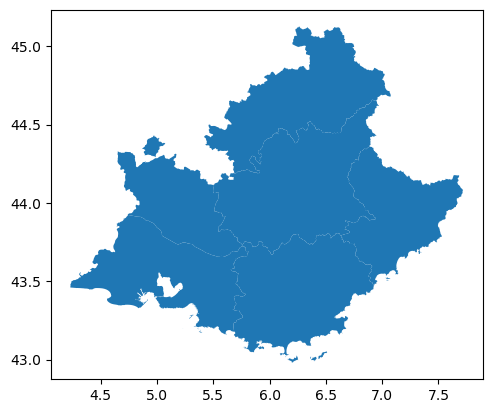

,fid,id,code,NOM,coderegion,region,geometry
0,1.0,05,05,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur,"POLYGON ((5.95112 44.75962, 5.95166 44.76019, ..."
1,2.0,04,04,Alpes-de-Haute-Provence,93,Provence-Alpes-Côte d'Azur,"POLYGON ((5.63131 44.15042, 5.63345 44.15060, ..."
2,3.0,83,83,Var,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((6.25870 42.99672, 6.25865 42.9..."
3,4.0,13,13,Bouches-du-Rhône,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((5.38534 43.18909, 5.38521 43.1..."
4,5.0,84,84,Vaucluse,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((4.89536 44.33817, 4.89156 44.3..."
5,6.0,06,06,Alpes-Maritimes,93,Provence-Alpes-Côte d'Azur,"MULTIPOLYGON (((7.07377 43.51540, 7.07384 43.5..."


Cartes sauvegardés en fichiers PNG dans X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025


In [45]:
# Cartes pour tous les paramètres sous forme de subplots
#================================
# Auteur: L. Duffar
# Mars 2024
#================================
import locale
import matplotlib.image as mpimg

locale.setlocale(locale.LC_ALL, 'fr_FR.UTF-8')

#========= Personalisation
# Dates de la période d'intérêt (les dates de données mensuelles SIM2 sont au 1er du mois)
date_debut= '2025-06-01'
date_fin= '2025-07-01'

#========= Initialisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))
print("Patientez !!! Attendez le message de fin de sauvegarde des cartes PNG !!!!")
file_logo= r'X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\icones\LOGO_SCP_BICHRO_DECC_petit.png'
file_logo= r'X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\logos\HydroClim - Logo_petit.png'
crs= ccrs.PlateCarree()
if os.path.exists(file_logo):
    logo = mpimg.imread(file_logo)

# Fonction pour tracer les cartes cartopy
def subplots_raw_param_one_date(da= None, crs= ccrs.PlateCarree(), date= '200-01-01', polyg_gdf= None):
    '''Fonction pour tracer pour une date donnée sur une page, les cartes de tous les paramètres bruts prédéterminés
    '''
    # TODO le nombre de lignes devrait s'adapter au nombre de subplots à tracer sur 2 colonnes
    fig, axs = plt.subplots(3, 2, figsize= (22, 29), dpi= 100, subplot_kw= dict(projection=crs))
    plt.subplots_adjust(hspace=0.0, wspace=0.1)
    
    # ajoute un titre à la figure
    mois_annee= pd.to_datetime(date).strftime('%B %Y')
    fig.suptitle(f'Paramètres climatiques mensuels SIM2 (Météo-France) - {pd.to_datetime(date).strftime("%B %Y")}', fontsize= 30, y= 0.92)

    # Obtenir les dimensions de la figure pour positionner le logo (en pixels)
    dpi = fig.get_dpi()
    fig_width_pixels = dpi * fig.get_figwidth()
    fig_height_pixels = dpi * fig.get_figheight()
    # Calculer la position du logo (en pixels)
    logo_height, logo_width, _ = logo.shape
    logo_x = fig_width_pixels - logo_width 
    logo_y = fig_height_pixels - logo_height

    # ajouter une icone SCP, en haut à droite (image originale de taille adaptée) ======== POSITION NON OBTENUE ============
    # fig.figimage(logo, xo= logo_x, yo= logo_y, origin= 'lower', zorder= 1) # positionne le logo en bas à droite
    # fig.figimage(logo, xo= 10, yo= 10, origin= 'upper', zorder= 1) # positionne le logo en bas à gauche
    axs= axs.flatten()

    # Boucle sur les différents paramètres
    for i, param in enumerate(list(param_dict.keys())[:6]):
        # Gestion de la colormap et des valeurs min et max (et du centre pour T_MENS)
        cmap= param_dict[param][2]
        vmin= param_dict[param][3][0]
        vmax= param_dict[param][3][2]
        vcenter= param_dict[param][3][1]
        if param== 'T_MENS':
            norm= matplotlib.colors.TwoSlopeNorm(vmin= vmin, vcenter= vcenter, vmax= vmax)
        else:
            norm= None
        
        # tracer la carte du paramètre pour cet axes
        img = da[param].plot(ax= axs[i], transform= crs, cmap= cmap, 
                             add_colorbar= False, vmin= vmin, vmax= vmax, norm= norm)
        
        # afficher le mois-année en haut à gauche & la valeur maximale en dessous
        mois_annee= pd.to_datetime(date).strftime('%B %Y') # mois année
        val_max= f'Max: {da[param].max().values.item():.1f} {param_dict[param][1]}' # valeur maximale
        val_min= f'Min: {da[param].min().values.item():.1f} {param_dict[param][1]}' # valeur min
        axs[i].annotate(mois_annee + '\n' + val_max+ '\n' + val_min,
                        xy=(0.02, 0.85), xycoords='axes fraction', fontsize=20, ha='left')

        # Colorbar : réglage de sa position/taille/graduation & ajout d'un label
        if vmax!= None and da[param].max().values.item() > vmax and vmin!= None and da[param].min().values.item() < vmin:# Vérifiez si les données dépassent vmax
            extend = 'both'
        elif vmin!= None and da[param].max().values.item() > vmax:
            extend = 'max'
        elif vmin!= None and da[param].min().values.item() < vmin:
            extend = 'min'
        else:
            extend = 'neither'
        cbar = plt.colorbar(img, ax=axs[i], fraction= 0.042, pad= 0.01, extend= extend) # extend permet de signaler par un triangle en haut de la colorbar que le maximum est dépassé
        cbar.set_label(param_dict[param][1], size= 15) # Ajouter un label à la colorbar
        cbar.ax.tick_params(labelsize= 15) # régler la taille de police des graduations de la colorbar
        # polygones
        polyg_gdf.plot(ax= axs[i], facecolor= 'none', edgecolor= 'black', linewidth= 1)   # polygones de gdf
        # Habillage
        axs[i].add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
        axs[i].add_feature(cfeature.RIVERS)                                         # rivières
        axs[i].add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair
        axs[i].add_feature(cfeature.NaturalEarthFeature('physical', 'lakes_europe', '10m', edgecolor='none', facecolor='cornflowerblue')) # permet d'ajouter n'importe quel couche connue de https://www.naturalearthdata.com/
        axs[i].add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor='#95B6DE')) # rien de plus sur PACA
        # Titre
        axs[i].set_title(f'{param_dict[param][0]} ({param_dict[param][1]})')
        axs[i].title.set_fontsize(25)
    # plt.show()
    fig.savefig(os.path.join(folder_out, file_out_name_root + pd.to_datetime(date).strftime('%Y-%m') + '.png'),
                bbox_inches='tight') # 'tigth' évite l'ajout de marges supplémentaires lors de la sauvegarde en fichier
    
    return fig

#========= Lecture du fichier shapefile de polygones
gdf = gpd.read_file(file_polygones)
# renomme la colonne des identifiants de polygones
gdf.rename(columns={ nom_champ_polygone: nom_colonne_polygone}, inplace=True)
# attributive_table = gdf.drop(columns= gdf.geometry.name)
# attributive_table
gdf.plot()
plt.show()
display(gdf)

#========== Carte cartopy
plt.ioff() # éviter l'affichage

# Boucles sur les dates (mois) de toute la période choisie
for date in pd.date_range(date_debut, date_fin, freq= 'MS'):
    da= ds_latlon.sel(DATE= date)
    fig= subplots_raw_param_one_date(da= da, crs= crs, date= date, polyg_gdf= gdf)
    plt.close(fig)
print('Cartes sauvegardés en fichiers PNG dans ' + folder_out)

#### 7- Dataframe de la moyenne des mailles pour chaque polygone et chaque paramètre --> fichier EXCEL 

Le fichier excel sera nécessaire au script de traitement agrégé par polygone

Le code traite touts les paramètres/colonnes présents dans le dataframe issu du fichier Météo-France (même si la cartographie par la suite ne restituera que certains paramètres prédéterminés)

NB: le dataframe est indexé selon (nom_colonne_polygone, 'DATE') (la valeur de nom_colonne_polygone est tirée du nom de colonne choisi par l'utilisateur dans la table attributive de gdf )

In [48]:
#================================
# Auteur: L. Duffar
# Mars 2024
#================================
# Boucle sur les polygones de gdf (geodatrame tiré du fichier shapefile des polygones)
    # pour chaque polygone, extraire les mailles qui sont contenues dans le polygone
    # calculer des données statistiques pour chaque paramètre météorologique
    # ajouter une ligne au dataframe unique pour chaque donnée statistique
    # ajouter le nom du polygone dans la colonne 'NOM_POLYGONE'
# fin de la boucle

########### Personalisation 
# ---------- > voir une cellule précédente

########### Traitements
print(datetime.now().strftime('%d/%m/%y %H:%M'))
# Création du DataFrame résultat
df = pd.DataFrame()

# itération sur les polygones / lignes du GeoDataFrame
for _, row in gdf.iterrows(): 
    polygone = row['geometry'] # objet shapely Polygon
    # display(polygone)
    
    #   Clipping des mailles contenues dans le polygone https://corteva.github.io/rioxarray/html/rioxarray.html 
    #       'invert= False' (défaut) pour conserver les mailles qui sont dans le polygone (et non l'inverse)
    #       'drop= True' If True, drop the data outside of the extent of the mask geoemtries Otherwise, it will return the same raster with the data masked (avec des NaN ?). Default is True.
    #       'all_touched= False' (default)  If false, only pixels whose center is within the polygon or that are selected by Bresenham’s line algorithm will be burned in. If True, all pixels touched by geometries will be burned in. 
    #       'from_disk=True' (lazy loading) pour économiser la mémoire si nécessaire. Ainsi l'objet généré par clip() n'est effectivement calculé que quand nécessaire par la suite
    ds_polygone = ds_latlon.rio.clip(geometries= [polygone], crs=4326, invert= False, drop= True, all_touched= False, from_disk= True) 
    #   remplace par NaN les valeurs trés élevées générées par la méthode rioxarray.rio.reproject qui ne gère pas correctement les NaN
    ds_polygone = ds_polygone.where(ds_polygone < seuil_filtre, other= float('nan'))
        
    # # TEMPORAIRE POUR VERIFICATION DU CLIPPING : Cartes d'un mois unique
    # print(row[nom_colonne_polygone], ds_polygone['T_MENS'][7].count().values) # calculer le nombre de pixels non NaN dans ds_polygone
    # gdf[gdf[nom_colonne_polygone]== row[nom_colonne_polygone]].plot(facecolor= 'none', edgecolor= 'black', linewidth= 1)# plot objet shapely polygone sans couleur de fond
    # ds_polygone['T_MENS'][7].plot() # plot raster de la température et 1ère observation non NaN
    # plt.show()

    #   Calcul de la moyenne pour chaque paramètre météorologique
    df_moyennes = ds_polygone.mean(dim= ["x", "y"], skipna=True).to_dataframe().reset_index()
    # display(df_moyennes)
    df_moyennes[nom_colonne_polygone] = row[nom_colonne_polygone]  # Ajout d'une colonne nom du polygone
    #   Concaténation au DataFrame résultat
    df = pd.concat([df, df_moyennes], ignore_index=True)

# Indexation et trie du DataFrame final
df.set_index([nom_colonne_polygone, 'DATE'], inplace=True)
df.sort_index(inplace= True)
# supprime la colonne spatial_ref inutile
df.drop(columns= 'spatial_ref', inplace= True)

# supprime l'Index
# df.reset_index(inplace= True)
# Sauvegarde du DataFrame résultat dans un fichier
start= df.index.get_level_values('DATE').min()
end= df.index.get_level_values('DATE').max()
period_full= f'{start.strftime("%Y")}-{start.strftime("%m")}_{end.strftime("%Y")}-{end.strftime("%m")}'
file_base= os.path.join(folder_out, file_out_name_root + period_full + "_polygones")
df.reset_index(drop= False).to_excel(file_base + ".xlsx", sheet_name= 'data', index= False) # fichier Excel
# enregistre un fichier parquet
# df.reset_index(drop= False).to_parquet(file_base + ".parquet") # fichier Parquet

print("Fichier Excel (historique par polygone) sauvegardé dans " + folder_out)
df

02/08/25 21:17
Fichier Excel (historique par polygone) sauvegardé dans X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025


PRENEI_MENS  PRETOTM_MENS     PE_MENS     T_MENS  \
NOM             DATE                                                           
Alpes-Maritimes 1958-08-01     0.000000     59.301639   -3.132787  17.165574   
                1958-09-01     0.000000     91.640984   49.157377  15.163934   
                1958-10-01     0.321311    114.777049   67.673770   9.570492   
                1958-11-01     7.696721     90.554098   70.477049   6.019672   
                1958-12-01    75.139344    312.218033  299.740984   2.642623   
...                                 ...           ...         ...        ...   
Vaucluse        2025-03-01     0.622449    121.530612   68.487755   8.791837   
                2025-04-01     0.000000     99.451020   28.830612  13.044898   
                2025-05-01     0.000000     61.946939  -38.875510  16.638776   
                2025-06-01     0.000000     17.330612  -47.538776  24.124490   
                2025-07-01     0.000000     32.159184  -18.385714  23.469388   

                             EVAP_MENS    ETP_MENS  SWI_MENS  SSWI1_MENS  \
NOM             DATE                                                       
Alpes-Maritimes 1958-08-01   62.444262  136.052459  0.380869    0.923770   
                1958-09-01   42.495082   89.337705  0.347869    0.214590   
                1958-10-01   47.106557   51.513115  0.709869    0.608197   
                1958-11-01   20.080328   25.009836  0.749590   -0.331967   
                1958-12-01   12.424590   22.555738  0.931508    0.541639   
...                                ...         ...       ...         ...   
Vaucluse        2025-03-01   53.032653   67.226531  0.796673    0.662653   
                2025-04-01   70.618367   89.144898  0.782714    1.469184   
                2025-05-01  100.834694  149.426531  0.695878    0.790816   
                2025-06-01   64.869388  197.487755  0.424143   -0.220816   
                2025-07-01   50.546939  202.059184  0.275469   -0.393878   

                            SSWI3_MENS  SSWI6_MENS  SSWI12_MENS  
NOM             DATE                                             
Alpes-Maritimes 1958-08-01         NaN         NaN          NaN  
                1958-09-01         NaN         NaN          NaN  
                1958-10-01    0.527705         NaN          NaN  
                1958-11-01    0.209180         NaN          NaN  
                1958-12-01    0.298197         NaN          NaN  
...                                ...         ...          ...  
Vaucluse        2025-03-01   -0.343673   -0.577347    -0.144082  
                2025-04-01    0.641020   -0.466327    -0.123061  
                2025-05-01    1.117143   -0.043673    -0.096122  
                2025-06-01    0.709184    0.231633    -0.145102  
                2025-07-01    0.168571    0.505510    -0.206122  

[4824 rows x 11 columns]

#### 8- Carte interactive/animée d'un paramètre choisi OPTIONNEL
FONCTIONNEMENT IMPARFAIT :
- environnement python38 : à moitié fonctionnel (OK dans le notebook, mais le fichier html généré ne s'anime pas dans le navigateur internet bien qu'il s'affiche)

In [35]:
#================================
# Auteur: L. Duffar
# Mars 2024
#================================
import hvplot.xarray
import panel as pn
print('Version hvplot:', hvplot.__version__)

############ Personalisation
# param= 'PRETOTM_MENS'
param= 'SSWI1_MENS'
date_start= '2025-01-01'
# date_start= '2024-03-01'
date_end= '2025-07-01'

############ Initialisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))

if 'SSWI' in param: # si le paramètre est un indice standardisé d'humidité du sol
    cmap= 'RdBu' # colormap pour les indices standardisés d'humidité du sol
    clim= (-2.5, +2.5) 
else:
    cmap= param_dict[param][2] # colormap pour les autres paramètres
    clim= (param_dict[param][3][0], param_dict[param][3][0])

# # transforme  cmap_precip de type 'LinearSegmentedColormap' en liste
# cmap = [cmap_precip(i) for i in range(cmap_precip.N)]

start= pd.to_datetime(date_start)
end= pd.to_datetime(date_end)
da_to_plot= ds_latlon[param].sel(DATE= slice(start, end))
    
############# Traitement
hvplot_by_month= da_to_plot.hvplot(x='x', y='y',
                        groupby= "DATE",  # groups by time 
                        # add title with date
                        # title= f"{param_dict[param][0]} ({param_dict[param][1]})",# si on spécifie le titre, il remplace la date par défaut qui est difficilement implémentable
                        widget_type= "scrubber", # AND adds a widget for time 'individual', 'scrubber' (arguments 'slider' et 'tabs' abandonnés dans hvplot 0.7.0 )
                        widget_location= "bottom",
                        width= 900, height= 600, 
                        alpha= 0.6, geo= True,  crs= ccrs.PlateCarree(), clim= clim,
#                        coastline= '10m',
                        tiles= 'CartoLight', cmap= cmap, clabel= param_dict[param][1],
                        )

# save hvplot_by_month to file 
period= f'{start.strftime("%Y")}-{end.strftime("%Y")}'
# ficher html : Avec python 3.11 le fichier html ne s'anime pas dans le navigateur web (mais s'anime dans le notebook, du moins quand il s'affiche)
html_name= file_out_name_root + param + "_" + pd.to_datetime(date).strftime('%Y-%m') +'.html'
# hvplot_by_month.save(os.path.join(folder_out, html_name))# non animé dans le navigateur web (cause probable : python 3.11)
pn.extension('bokeh')
pn.panel(hvplot_by_month).save(os.path.join(folder_out, html_name + '.html'), embed=True)# résoud le problème de l'animation dans le navigateur web

print("Animation html sauvegardée dans ", folder_out)
print()
print("Paramètre :", param)

if 'SSWI' in param:
    print("Les paramètres SSWI traduisent l'humidité du sol en période de retour selon l'équivalence suivante:")
    # display sans index 
    display(df_sswi.style.hide(axis='index').set_caption("Période de retour des indices SSWI var.normale.centrée réduite"))

hvplot_by_month

Version hvplot: 0.9.2
02/08/25 20:49


Animation html sauvegardée dans  X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025

Paramètre : SSWI1_MENS
Les paramètres SSWI traduisent l'humidité du sol en période de retour selon l'équivalence suivante:


Période de retour,SSWI
Médiane,0
5 ans,+/-0.842
10 ans,+/-1.282
20 ans,+/-1.645
50 ans,+/-2.054
100 ans,+/-3.090


BokehModel(combine_events=True, render_bundle={'docs_json': {'2aab7978-9e2b-47a9-9902-390002259d62': {'version…

#### 9- Carte de moyenne inter annuelle pour TOUS paramètres et la période choisis - OBLIGATOIRE POUR GENERER les cartes d'écart à la moyenne à partir de dataset ds_mean

NB: Moyennes interannuelles calculées pour TOUS les paramètres fixés (ds_mean), dont pour 1 paramètre choisi (da_mean/da_mean_yearly)

- En revanche la carte ne peut traiter n'importe quel paramètre ou région (PACA, Bassin Verdon-Durance), qu'à condition de définir vmin et vmax de la colormap annuelle de façon adaptée à chaque cas de figure (pour l'instant uniquement la zone PACA et les paramètres pluie, SWI, ETR, ETP & NEIGE).
- Par exemple la température est pour l'instant non cartographiable. La colormap divergente doit être redéfinie, car elle doit être centrée sur zéro, et celle définie pour la valeurs de chaque année n'est pas valable
- Cartes sauvegardées en images PNG et en fichier geoTIF

02/08/25 20:50


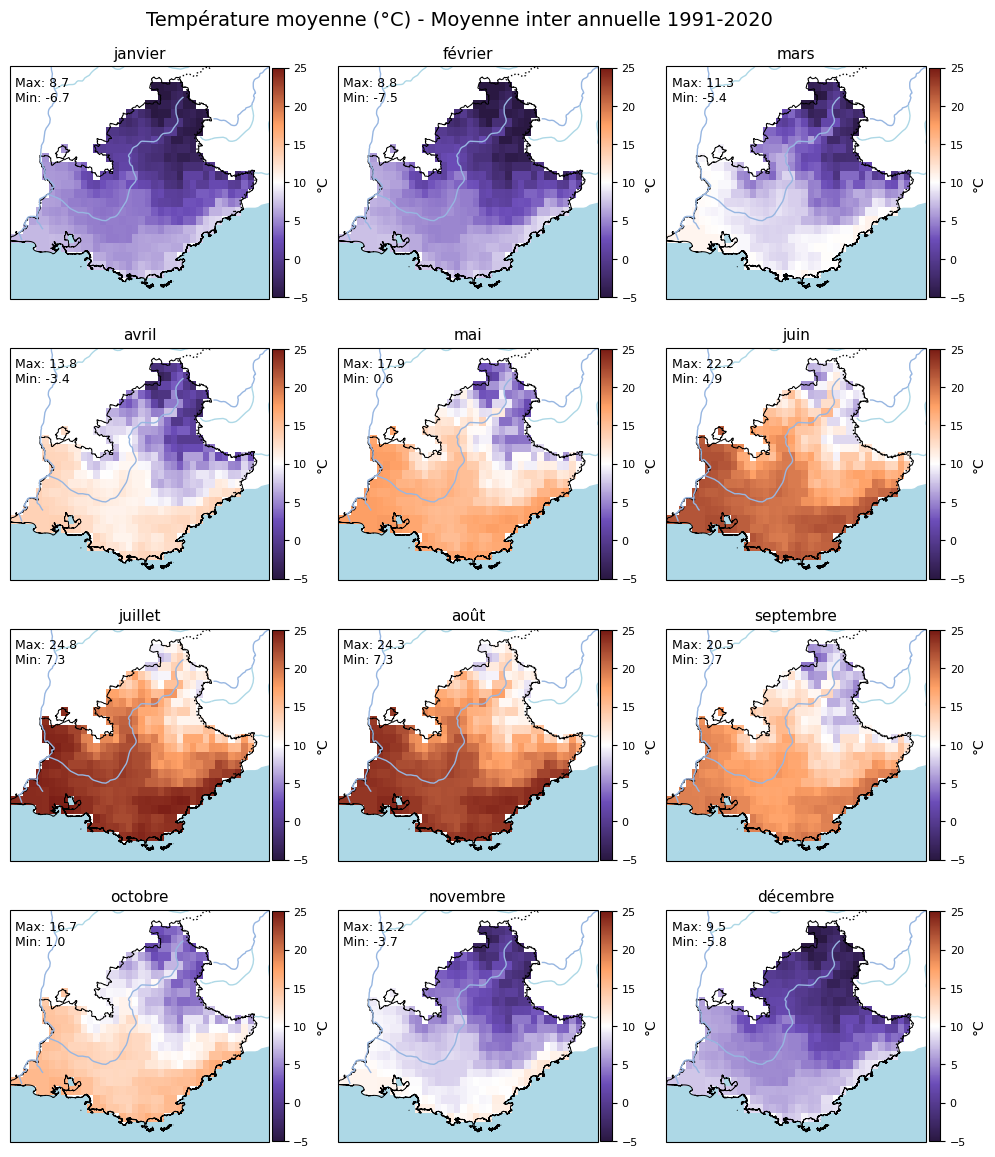

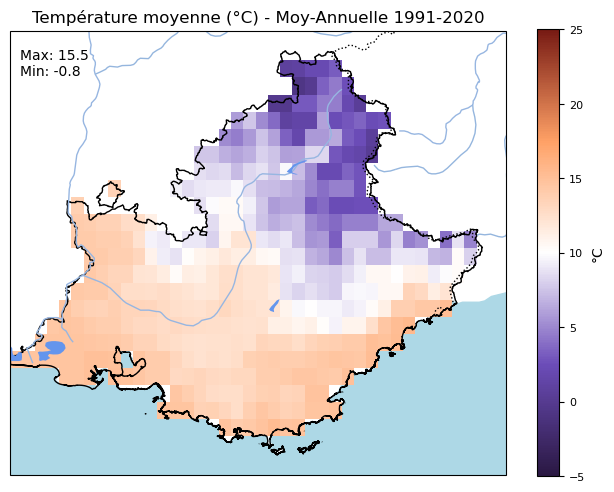

Cartes sauvegardées en fichiers PNG et geotif dans X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025


In [36]:
#================================
# Auteur: L. Duffar
# Avril 2024
#================================

# %matplotlib notebook NON UTILISE MAIS ALTERNATIVE THEORIQUE A %matplotlib inline
# "%matplotlib inline" POUR afficher une figure dans un notebook Jupyter permet de se dispenser de plt.show(). plt.show() reste cependant utilisable et est même indispensable dans un contexte multifigures pour éviter un double affichage
%matplotlib inline 

############### Personalisation #################################
# param= 'PRETOTM_MENS'
# param= 'SWI_MENS'
# param= 'SSWI1_MENS'
# param= 'EVAP_MENS'
param= 'T_MENS'
# param= 'PRENEI_MENS'
# param= 'ETP_MENS'

# DAtes mensuelles avec 01 comme jour
date_start= '1991-01-01'
# date_start= '2024-03-01'
date_end= '2020-01-01'

############### Carte des moyennes mensuelles pour chaque mois  #################################
#============== Initialisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))
start= pd.to_datetime(date_start)
end= pd.to_datetime(date_end)
period= f'{start.strftime("%Y")}-{end.strftime("%Y")}'

# Gestion de la colormap et des valeurs min et max (et du centre pour T_MENS) pour les cartes mensuelles
title= param_dict[param][0]
unite= param_dict[param][1]
# cmap= cmap_precip
cmap= param_dict[param][2]
vmin= param_dict[param][3][0]
vmax= param_dict[param][3][2]
vcenter= param_dict[param][3][1]
norm= None

if 'SSWI' in param:
    print("Pour les paramètres SSWI la moyenne internnuelle n'est pas forcément pertinente")
    print("En effet les paramètres SSWI traduisent déjà en période de retour l'humidité du sol.")
    print("La couleur traduit donc le fait que la moyenne n'est pas équivalente à la médiane. Sinon la carte serait blanche")
    # display sans index 
    display(df_sswi.style.hide(axis='index').set_caption("Période de retour des indices SSWI var.normale.centrée réduite"))

#============== Traitement
# calculer la moyenne interannuelle par mois
da_mean= ds_latlon[param].sel(DATE= slice(start, end)).groupby('DATE.month').mean('DATE', skipna= False)
# générer un dataset contenant la moyenne interannuelle par mois, sur tous le dataset ds_latlon
ds_mean= ds_latlon.sel(DATE= slice(start, end)).groupby('DATE.month').mean('DATE', skipna= False)

# supprime la dimension spatial_ref
# da_mean= da_mean.drop_vars('spatial_ref')
da_mean= ds_mean[param].drop_vars('spatial_ref')

# subplots pour chaque mois de da_mean
fig, axs = plt.subplots(4, 3, figsize=(12, 14), dpi= 100, subplot_kw= dict(projection=ccrs.PlateCarree()))

# ajoute un titre à la figure
titre= f'{title} ({unite})' + ' - Moyenne inter annuelle ' + period
fig.suptitle(titre, fontsize= 14, y= 0.92)

# Tracer les cartes cartopy de da_mean pour les 12 mois
for i, month in enumerate(da_mean.month.values):
    '''Une page de subplots pour tous les mois'''

    # tracer la carte du paramètre
    img = da_mean.sel(month= month).plot(ax= axs.flatten()[i], transform= ccrs.PlateCarree(), cmap= cmap, 
                         add_colorbar= False, vmin= vmin, vmax= vmax, norm= norm)
    # Titre de chaque subplot
    nom_mois= pd.to_datetime(month, format='%m').strftime('%B')
    axs.flatten()[i].set_title(nom_mois, fontsize= 11)

    # afficher la valeur maximale en haut à gauche
    val_max= f'Max: {da_mean.sel(month= month).max().values.item():.1f}' # valeur maximale
    val_min= f'Min: {da_mean.sel(month= month).min().values.item():.1f}' # valeur min
    axs.flatten()[i].annotate(val_max + '\n' + val_min,
                    xy=(0.02, 0.85), xycoords='axes fraction', fontsize= 9, ha='left')

    # Colorbar : réglage de sa position/taille/graduation & ajout d'un label
    if vmax!= None and da_mean.sel(month= month).max().values.item() > vmax:# Vérifiez si les données dépassent vmax
        extend = 'max'
    else:
        extend = 'neither'
    cbar = plt.colorbar(img, ax=axs.flatten()[i], fraction= 0.042, pad= 0.01, extend= extend) # extend permet de signaler par un triangle en haut de la colorbar que le maximum est dépassé 
    cbar.set_label(unite, size= 10) # Ajouter un label à la colorbar
    cbar.ax.tick_params(labelsize= 8) # régler la taille de police des graduations de la colorbar

    # Habillage
    gdf.plot(ax= axs.flatten()[i], facecolor= 'none', edgecolor= 'black', linewidth= 0.7)   # polygones de gdf
    # axs.flatten()[i].add_feature(cfeature.COASTLINE)                                      # côtes
    axs.flatten()[i].add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
    # axs.flatten()[i].add_feature(cfeature.LAKES, alpha= 0.5)                              # lacs
    axs.flatten()[i].add_feature(cfeature.RIVERS)                                         # rivières
    axs.flatten()[i].add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor='lightblue')) # rien de plus sur PACA
    axs.flatten()[i].add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair

plt.show()
file_name= file_out_name_root + period + '_' + param + "_" +  '_Moy-Mens'
fig.savefig(os.path.join(folder_out, file_name +'.html' + '_Moy-Mens.png'),
            bbox_inches='tight') # 'tigth' évite l'ajout de marges supplémentaires lors de la sauvagarde

############## carte de la moyenne ANNUELLE interannuelle par maille #################################
if 'SSWI' not in param: # si le paramètre n'est pas un indice standardisé d'humidité du sol
 
    #============= Initialisation
    # Gestion de la colormap et des valeurs min et max (et du centre pour T_MENS) pour la carte annuelle
    vmin= param_dict[param][4][0]
    vmax= param_dict[param][4][2]
    vcenter= param_dict[param][4][1]

    if param_dict[param][5] == 'sum':
        da_mean_yearly= ds_latlon[param].sel(DATE= slice(start, end)).groupby('DATE.year').sum('DATE', skipna= False)
    elif param_dict[param][5] == 'mean':
        da_mean_yearly= ds_latlon[param].sel(DATE= slice(start, end)).groupby('DATE.year').mean('DATE', skipna= False)
    da_mean_yearly= da_mean_yearly.mean('year', skipna= False)
    
    #=============  Carte
    fig, ax = plt.subplots(1, 1, figsize= (8, 5.8), dpi= 100, subplot_kw=dict(projection= ccrs.PlateCarree()))
    # Cartographie du paramètre
    p= da_mean_yearly.plot(ax= ax, transform= ccrs.PlateCarree(), cmap= cmap, add_colorbar= True, vmin= vmin, vmax= vmax, norm= norm)
    # personalisation de la colorbar par défaut
    cbar= p.colorbar
    cbar.set_label(unite, size= 10) # taille de la légende de colorbar
    cbar.ax.tick_params(labelsize= 8) # taille de police des graduations de la colorbar
    # Titre
    # plt.title(f'{param_dict[param][0]} ({param_dict[param][1]}) - Moy-Annuelle {start.strftime("%Y")}-{end.strftime("%Y")}', 
    plt.title(f'{title} ({unite}) - Moy-Annuelle ' + period, 
            fontsize= 12)                                          
    # afficher les valeurs min/max en haut à gauche
    val_max= f'Max: {da_mean_yearly.max().values.item():.1f}' # valeur maximale
    val_min= f'Min: {da_mean_yearly.min().values.item():.1f}' # valeur min
    ax.annotate(val_max + '\n' + val_min,
                    xy=(0.02, 0.9), xycoords='axes fraction', fontsize=10, ha='left')

    # Colorbar : réglage de sa position/taille/graduation & ajout d'un label
    if vmax!= None and da_mean_yearly.max().values.item() > vmax:# Vérifiez si les données dépassent vmax
        extend = 'max'
    else:
        extend = 'neither'
    cbar = plt.colorbar(img, ax=axs.flatten()[i], fraction= 0.042, pad= 0.01, extend= extend) # extend permet de signaler par un triangle en haut de la colorbar que le maximum est dépassé 
    cbar.set_label(unite, size= 10) # Ajouter un label à la colorbar
    cbar.ax.tick_params(labelsize= 8) # régler la taille de police des graduations de la colorbar

    # Habillage
    img= gdf.plot(ax= ax, facecolor= 'none', edgecolor= 'black', linewidth= 1)   # polygones de gdf
    ax.add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
    ax.add_feature(cfeature.RIVERS)                                         # rivières
    ax.add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'lakes_europe', '10m', edgecolor='none', facecolor='cornflowerblue')) # permet d'ajouter n'importe quel couche connue de https://www.naturalearthdata.com/
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor='#95B6DE'))  # rien de plus sur PACA

    plt.show()
    file_year= file_out_name_root + period + '_' + param + "_" + '_Moy-Annuelle'
    fig.savefig(os.path.join(folder_out, file_year) + '.png', bbox_inches= 'tight') # 'tigth' évite l'ajout de marges supplémentaires lors de la sauvagarde

    # sauvegarde du fichier image tif
    da_mean_yearly.rio.to_raster(os.path.join(folder_out, file_year) + '.tif')
print(f'Cartes sauvegardées en fichiers PNG et geotif dans ' + folder_out)

#### 10- Carte d'écart à la moyenne pour une date choisie et 1 paramètre choisi parmi 6 fixés --> dataarray da_ratio 
Pour la date, période, et région choisis - Pour 1 des 6 paramètres fixés<br>
(pour d'autres paramètres climatiques, les réglages du graphique doivente être définis)

02/08/25 19:45
Pour les indices SSWI cette carte d'écart à la moyenne interannuelle n'a pas de sens car les indice SSWI expriment déjà la période de retour de l'excédent/déficit


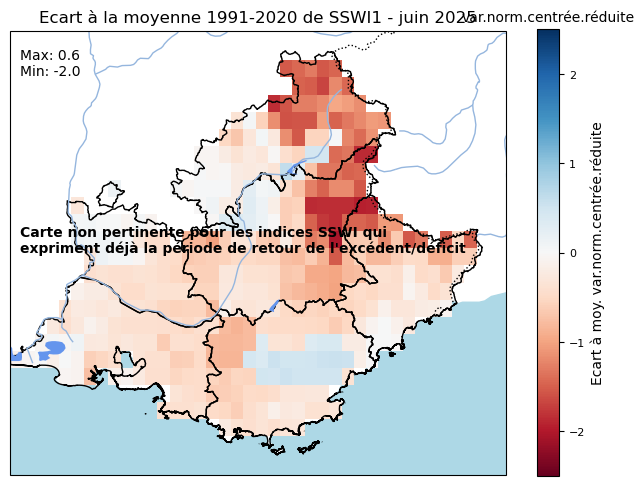

Carte sauvegardée en PNG dans X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out_2025


In [24]:
#================================
# Auteur: L. Duffar
# Avril 2024
#================================

############### Personalisation DU PARAMETRE ET DE LA DATE ###############
# param= 'SWI_MENS'
param= 'SSWI1_MENS'
# param= 'EVAP_MENS'
# param= 'PRETOTM_MENS'
# param= 'PRENEI_MENS'
# param= 'T_MENS'
# param= 'ETP_MENS'

date_map= '2025-06-01' # la date mensuelle SIM2 est le 1er du mois

############### Carte #################################
print(datetime.now().strftime('%d/%m/%y %H:%M'))
#============== Initialisation
# Bornes min et max pour la colormap du ratio
vmin= 0.5
vmax= 1.5
# Gestion de la colormap et des valeurs min et max (et du centre pour T_MENS)
# ! DEFINITION COMMUNE AVEC LE SCRIPT suivant de la chaine de traitement (traitement par polygone), mais tout n'est pas utile dans le présent script
sec_humide= ['sec', 'humide']
froid_chaud= ['froid', 'chaud']
faible_fort= ['faible', 'fort']
non_pertinent= None # pour le script "traitement par polygone" cette variable concernant la période de retour n'est pas pertinente pour les indices SSWI qui représentent déjà une période de de retour
nom_colonnes= ['nom_clair',           'unité', 'cbar_écart',              'grad_écart', 'bas_haut']
param_array= [
              ['Précip. solides',    "ratio", 'RdBu',                     [0, 4],      sec_humide], # 'PRENEI_MENS', 
              ['Précip. totales',    'ratio', 'RdBu',                     [0, 4],      sec_humide], # 'PRETOTM_MENS', 
              ['Température',        '°C', 'RdBu_r',                      [0, 5],     froid_chaud], # 'T_MENS', 
              ['Evaporation réelle', 'ratio', 'RdBu_r',                   [0, 4],     faible_fort], # 'EVAP_MENS', 
              ['ETP',                'ratio', 'RdBu_r',                   [0, 4],     faible_fort], # 'ETP_MENS', 
              ['SWI',                'ratio', 'RdBu',                     [0, 0.8],    sec_humide],# 'SWI_MENS',
              ['SSWI1',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI1_MENS',
              ['SSWI3',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI3_MENS', 
              ['SSWI6',              'var.norm.centrée.réduite', 'RdBu',  [0, +2.5],    non_pertinent],# 'SSWI6_MENS', 
              ['SSWI12',              'var.norm.centrée.réduite', 'RdBu', [0, +2.5],    non_pertinent],# 'SSWI12_MENS', 
            ]
nom_index= ['PRENEI_MENS', 'PRETOTM_MENS', 'T_MENS', 'EVAP_MENS', 'ETP_MENS', 'SWI_MENS', 'SSWI1_MENS', 'SSWI3_MENS', 'SSWI6_MENS', 'SSWI12_MENS']
param_df= pd.DataFrame(param_array, index= nom_index, columns= nom_colonnes)

cmap= param_df['cbar_écart'][param]
vcenter= param_df['grad_écart'][param][0]
vmax= param_df['grad_écart'][param][1]

vmin= vcenter - vmax
norm= None

#============== Carte
# Carte  pour date_map de l'écart entre les précipitations du mois et la moyenne interannuelle pour ce mois dans da_mean
# Calcul du ratio
# da_ratio= (ds_latlon[param].sel(DATE= date_map) -  da_mean.sel(month= pd.to_datetime(date_map).month)) / da_mean.sel(month= pd.to_datetime(date_map).month)
# da_ratio= (ds_latlon[param].sel(DATE= date_map) -  ds_mean[param].sel(month= pd.to_datetime(date_map).month)) / ds_mean[param].sel(month= pd.to_datetime(date_map).month)
if param== 'T_MENS' or 'SSWI' in param:
  da_ratio= (ds_latlon[param].sel(DATE= date_map) -  ds_mean[param].sel(month= pd.to_datetime(date_map).month))
else:
  da_ratio= (ds_latlon[param].sel(DATE= date_map) -  ds_mean[param].sel(month= pd.to_datetime(date_map).month)) / ds_mean[param].sel(month= pd.to_datetime(date_map).month)

# Figure
fig, ax = plt.subplots(1, 1, figsize=(8, 5.8), dpi= 100, subplot_kw=dict(projection= ccrs.PlateCarree()))

# Cartographie du paramètre
norm = matplotlib.colors.TwoSlopeNorm(vmin= vmin, vcenter= vcenter, vmax= vmax) # ATTENTION: le zéro n'est pas exactement au centre (pourquoi ?)
p= da_ratio.plot(ax= ax, transform= ccrs.PlateCarree(), cmap= cmap, add_colorbar= True, vmin= vmin, vmax= vmax, norm= norm)
# personalisation de la colorbar par défaut
cbar= p.colorbar
if param== 'T_MENS'or 'SSWI' in param: 
  cbar.set_label('Ecart à moy. ' + param_df['unité'][param], size=10)# légende de colorbar
  cbar.ax.set_title(param_df['unité'][param], size= 10) # titre de la colorbar
else:
  cbar.set_label('Ecart à moy./Moy. (Ratio)', size=10)# légende de colorbar
  cbar.ax.set_title('Ratio', size= 10)
cbar.ax.tick_params(labelsize= 8) # taille de police des graduations de la colorbar
  
# Titre
plt.title(f"Ecart à la moyenne " + period + f" de {param_df['nom_clair'][param]} - {pd.to_datetime(date_map).strftime('%B %Y')}",
          fontsize= 12)

# afficher les valeurs min/max en haut à gauche
val_max= f'Max: {da_ratio.max().values.item():.1f}' # valeur maximale
val_min= f'Min: {da_ratio.min().values.item():.1f}' # valeur min
ax.annotate(val_max + '\n' + val_min,
                xy=(0.02, 0.9), xycoords='axes fraction', fontsize=10, ha='left')

# Habillage
river_color= '#95B6DE' #couleur par défaut de cfeature.RIVERS
img= gdf.plot(ax= ax, facecolor= 'none', edgecolor= 'black', linewidth= 1)   # polygones de gdf
ax.add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
ax.add_feature(cfeature.RIVERS, edgecolor= river_color)                 # rivières
ax.add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'lakes_europe', '10m', edgecolor='none', facecolor='cornflowerblue')) # permet d'ajouter n'importe quel couche connue de https://www.naturalearthdata.com/
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor= river_color))  # rien de plus sur PACA (seulement Isère et 1 affluent du Pô)

if 'SSWI' in param: # si le paramètre est un indice standardisé d'humidité du sol
  print("Pour les indices SSWI cette carte d'écart à la moyenne interannuelle n'a pas de sens car les indice SSWI expriment déjà la période de retour de l'excédent/déficit")
  ax.annotate("Carte non pertinente pour les indices SSWI qui \nexpriment déjà la période de retour de l'excédent/déficit",
                  xy=(0.02, 0.5), xycoords='axes fraction', fontsize=10, fontweight='bold', ha='left')
plt.show()
file_ratio= os.path.join(folder_out, file_out_name_root +  period + '_' + param + '_Ecart_' + pd.to_datetime(date_map).strftime('%Y-%m'))
fig.savefig(file_ratio + '.png', bbox_inches= 'tight') # 'tigth' évite l'ajout de marges supplémentaires lors de la sauvagarde

# sauvegarde du fichier image tif
# da_ratio.rio.to_raster(file_ratio + '.tif')
print(f'Carte sauvegardée en PNG dans ' + folder_out)


#### 11- Carte de l'écart à la moyenne du CUMUL de précipitations depuis septembre (Maille par maille) 
##### EN COURS

Précipitations uniquement

In [11]:
# Générer un dataarray à partir de ds_latlon[param], en faisant le cumul depuis septembre 2023, de septembre 2023 au dernier mois disponible
# NB: uniquement la variable dataarray, pas de carte pour l'instant

#================================
# Auteur: L. Duffar
# Avril 2024
#================================

############### Personalisation #################################
param= 'PRETOTM_MENS'
date_start= '2023-09-01'
# date_start= '2024-03-01'
date_end= '2024-05-01'

############### Initialisation #################################
print(datetime.now().strftime('%d/%m/%y %H:%M'))
# Gestion de la colormap et des valeurs min et max (et du centre pour T_MENS)
# cmap= cmap_precip
cmap= param_dict[param][2]
vmin= param_dict[param][3][0]
vmax= param_dict[param][3][2]
vcenter= param_dict[param][3][1]
if param== 'T_MENS':
    norm= matplotlib.colors.TwoSlopeNorm(vmin= vmin, vcenter= vcenter, vmax= vmax)
else:
    norm= None

#============== Traitement
# calculer pour chaque mois le cumul depuis date_start
da_cumul= ds_latlon[param].sel(DATE= slice(date_start, date_end)).cumsum('DATE', skipna= False)
# supprime la dimension spatial_ref
da_cumul= da_cumul.drop_vars('spatial_ref')

da_cumul


02/07/25 19:30


<xarray.DataArray 'PRETOTM_MENS' (DATE: 9, y: 22, x: 38)> Size: 60kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * x        (x) float64 304B 4.273 4.364 4.455 4.546 ... 7.359 7.45 7.541 7.631
  * y        (y) float64 176B 45.03 44.94 44.85 44.76 ... 43.4 43.31 43.22 43.12
  * DATE     (DATE) datetime64[ns] 72B 2023-09-01 2023-10-01 ... 2024-05-01

#### 12- Carte de l'altitude OPTIONNEL

02/08/25 20:40


RasterioIOError: X:/1-COMMUN/DIS/Documentation/Hydrologie/Documentation externe/Climat Monde/WorldClim/Elevation/wc2.1_30s_elev.tif: No such file or directory

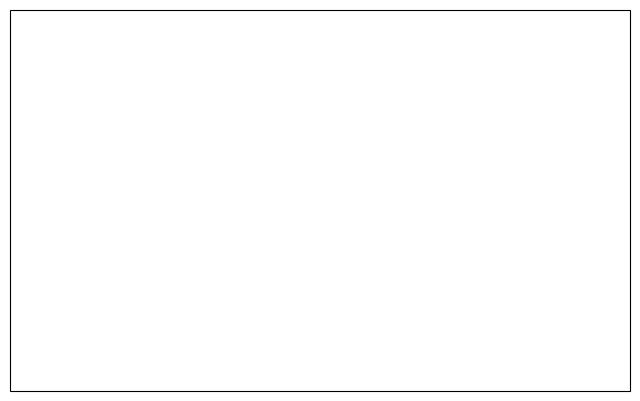

In [25]:
#================================
# Auteur: L. Duffar
# Avril 2024
#================================

#============== Personalisation
file_elev= r'X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat Monde\WorldClim\Elevation\wc2.1_30s_elev.tif'

#============== Initialisation
cmap= 'terrain'
nom= None
elev_min= -700
elev_max= 2900

#============== Visualisation
print(datetime.now().strftime('%d/%m/%y %H:%M'))

fig, ax = plt.subplots(1, 1, figsize=(8, 5.8), dpi= 100, subplot_kw=dict(projection= ccrs.PlateCarree()))

lat_min= gdf.bounds.miny.min()
lat_max= gdf.bounds.maxy.max()
lon_min= gdf.bounds.minx.min()
lon_max= gdf.bounds.maxx.max()
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs= ccrs.PlateCarree())

# lecture de l'image raster de l'élévation
da_elev= rioxarray.open_rasterio(file_elev)
da_elev= da_elev.sel(band= 1)
# Clip global data
da_elev= da_elev.rio.clip_box(lon_min, lat_min, lon_max, lat_max)
# Cartographie de l'élévation
# da_elev.plot.imshow(ax= ax, cmap= cmap, vmin= elev_min, vmax= elev_max, add_colorbar= True)
img_elev = da_elev.plot(ax= ax, cmap= cmap, vmin= elev_min, vmax= elev_max, add_colorbar= True)

# polygones
img= gdf.plot(ax= ax, facecolor= 'none', edgecolor= 'black', linewidth= 1)   # polygones de gdf

# Titre
plt.title('Altitude', fontsize= 12)

# Récupérer la colorbar
cbar = img_elev.colorbar

# Modifier la colorbar
cbar.set_label('Altitude (m)')

# habillage
river_color= 'royalblue' # '#95B6DE' couleur par défaut de cfeature.RIVERS
ax.add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
ax.add_feature(cfeature.RIVERS, edgecolor= river_color)                                         # rivières
ax.add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'lakes_europe', '10m', edgecolor='none', facecolor= 'cornflowerblue')) # permet d'ajouter n'importe quel couche connue de https://www.naturalearthdata.com/
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor= river_color)) # rien de plus sur PACA

plt.show()
fig.savefig(os.path.join(folder_out, file_out_name_root + '_Elevation.png'), bbox_inches= 'tight') # 'tigth' évite l'ajout de marges supplémentaires lors de la sauvagarde


#### Tests

<xarray.DataArray 'PRETOTM_MENS' (y: 22, x: 38)> Size: 7kB
array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,  0.1452107 ,  0.14717296,  0.14808638,
         0.14662897,  0.14310654,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,  0.14343372,  0.14447694,
         0.27169771,  0.14713388,  0.04349969,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
...
         2.09556139,  2.09949215,  2.03473162,  2.03445286,  1.83450439,
         1.83450439,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,  2.50469279,  2.50743991,  2.50743991,
         2.73897893,  2.4351126 ,  2.4319224 ,  2.4316274 ,  2.0958167 ,
         2.12217167,  2.03121461,  2.03486802,  2.03388041,  1.83730698,
         1.83730698,  1.83701711,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,  2.68314551,  2.43185435,  2.1149906 ,
         2.12500784,  2.34798965,  1.83477985,  1.83511764,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan]])
Coordinates:
  * x            (x) float64 304B 4.273 4.364 4.455 4.546 ... 7.45 7.541 7.631
  * y            (y) float64 176B 45.03 44.94 44.85 44.76 ... 43.31 43.22 43.12
    DATE         datetime64[ns] 8B 2025-03-01
    spatial_ref  int32 4B 0
    month        int64 8B 3

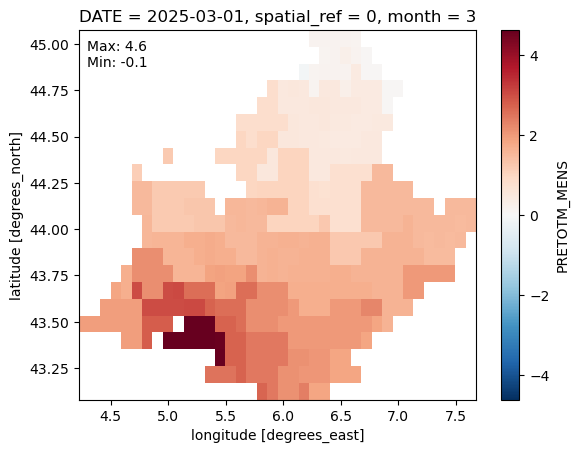

In [13]:
import panel as pn
import hvplot.pandas

############# Personalisastion
# dataarray= ds_latlon[param].sel(DATE= date_map)
dataarray= da_ratio
# dataarray= ds_mean[param].sel(month= pd.to_datetime(date_map).month)
# dataarray= (ds_latlon[param].sel(DATE= date_map) -  ds_mean[param].sel(month= pd.to_datetime(date_map).month)) / ds_mean[param].sel(month= pd.to_datetime(date_map).month)

############# afficher dans l'explorateur web le dataarray choisi, en passant par table= da_ratio.hvplot.table()
pn.extension()
dataframe= dataarray.to_dataframe()
table= dataframe.hvplot.table(width= 1500, height= 800)

# affiche la variable "table" dans l'explorateur web avec panel
# pn.serve(table)

fig, ax = plt.subplots(1, 1)
dataarray.plot()
# afficher les valeurs min/max en haut à gauche
val_max= f'Max: {dataarray.max().values.item():.1f}' # valeur maximale
val_min= f'Min: {dataarray.min().values.item():.1f}' # valeur min
ax.annotate(val_max + '\n' + val_min,
                xy=(0.02, 0.9), xycoords='axes fraction', fontsize=10, ha='left')

dataarray
